In [68]:
import importlib
import stochastic_interpolants
importlib.reload(stochastic_interpolants)
from stochastic_interpolants import *

from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Create MLP Model with sin/cos time embedding. Consult https://www.kaggle.com/code/lorentzyeung/positional-embeddings-clearly-explained for more information on this type of time embedding.

In [52]:
# image size
IMG_SIZE = 28
# input size
IN_S = IMG_SIZE ** 2
# hidden size
H_S = 1024
# amount of layers
L = 8
# output size
OUT_S = IN_S
# time dimensions
T_D = 128

model = MLP(input_size = IN_S, hidden_size = H_S, amount_layers = L, output_size = OUT_S, time_dimension = T_D)
model = model.to(device)

## Define Target Distribution

In [53]:
dataset_target = load_dataset("natejuw/mnist-28x28")

Generating train split: 100%|██████████| 10000/10000 [00:00<00:00, 77831.42 examples/s]


## Define Base Distribution

In [54]:
dataset_base = dataset_target.copy()
dataset_base["train"] = dataset_to_gaussian(dataset_base)

Map: 100%|██████████| 10000/10000 [00:05<00:00, 1743.85 examples/s]


## Prime the datasets for MLP

In [55]:
dataset_base["train"] = flatten_dataset(dataset_base)
dataset_target["train"]  = flatten_dataset(dataset_target)

dataset_base["train"].set_format("torch", columns=["pixel_values"])
dataset_target["train"].set_format("torch", columns=["pixel_values"])

Map: 100%|██████████| 10000/10000 [00:04<00:00, 2047.77 examples/s]


## Define Interpolant

In [56]:
interpolant = Interpolant('variance_preserve')

## Now we want to train the model.

In [65]:
model = model.to(device)

train_type = 'velocity'
gradient_steps = 10000
batch_size = 200
log_every = 200
base_learning_rate = 1e-3
weight_decay = 1e-7
out_name = "noise_to_mnist.pt"

interpolant.train_model(model = model, dataset_base = dataset_base, dataset_target = dataset_target, 
train_type = train_type, n_iterations = gradient_steps,
batch_size = batch_size, log_every = log_every, base_lr = 1e-3, weight_decay = 1e-7,
out_name = out_name)

step 200/10000 | obj -0.560003 | mse 1.260222 | grad_norm 0.1997 | pred_mean -0.7297 | I_mean -0.6873 | pred_std 0.8636
step 400/10000 | obj -0.613791 | mse 1.159718 | grad_norm 0.182 | pred_mean -0.7025 | I_mean -0.7044 | pred_std 0.8391
step 600/10000 | obj -0.582378 | mse 1.217290 | grad_norm 0.2046 | pred_mean -0.6304 | I_mean -0.6854 | pred_std 0.8225
step 800/10000 | obj -0.642224 | mse 1.086383 | grad_norm 0.1805 | pred_mean -0.7483 | I_mean -0.7849 | pred_std 0.8918
step 1000/10000 | obj -0.630325 | mse 1.115119 | grad_norm 0.1282 | pred_mean -0.7593 | I_mean -0.7444 | pred_std 0.8493
step 1200/10000 | obj -0.587371 | mse 1.203702 | grad_norm 0.1545 | pred_mean -0.7604 | I_mean -0.7263 | pred_std 0.8541
step 1400/10000 | obj -0.621134 | mse 1.132507 | grad_norm 0.1326 | pred_mean -0.752 | I_mean -0.7384 | pred_std 0.8553
step 1600/10000 | obj -0.567244 | mse 1.236061 | grad_norm 0.1794 | pred_mean -0.7231 | I_mean -0.7001 | pred_std 0.8506
step 1800/10000 | obj -0.624330 | mse 

## Now we view the flow
when we run the noise to mnist for 15,000 gradient steps we get the following, we can see that there is something there. this is with alpha(t)=cos(pi/2 t) and beta(t) = sin(pi/2 t) with gamma(t)=0.

starting from dataset item 2911


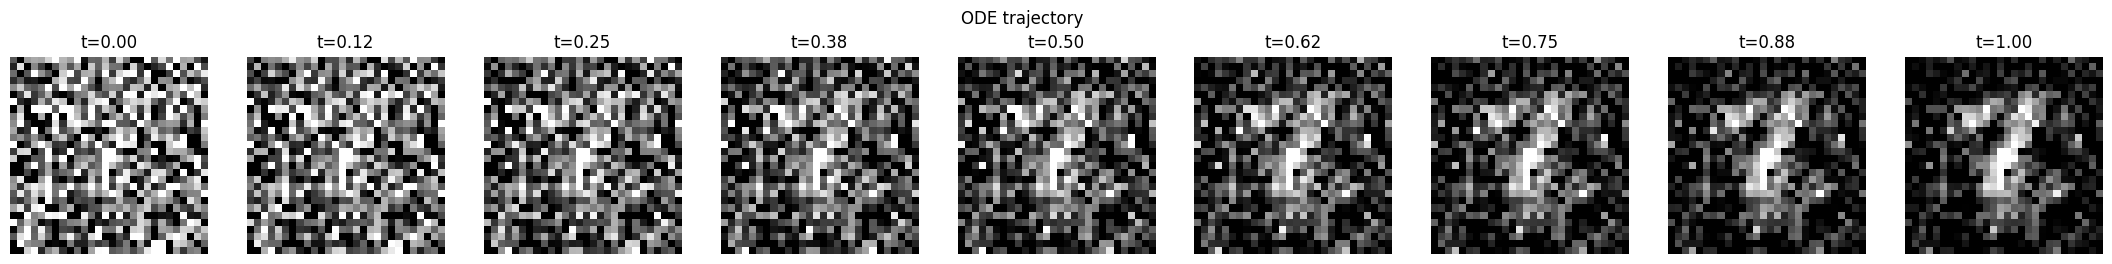

In [77]:
run_flow(dataset_base, model, n_steps = 2000, save_frames = 9, img_size = 28, use_random=True)

## Nonzero Gamma

In [72]:
# image size
IMG_SIZE = 28
# input size
IN_S = IMG_SIZE ** 2
# hidden size
H_S = 1024
# amount of layers
L = 8
# output size
OUT_S = IN_S
# time dimensions
T_D = 128

model_new = MLP(input_size = IN_S, hidden_size = H_S, amount_layers = L, output_size = OUT_S, time_dimension = T_D)
model_new = model_new.to(device)

In [69]:
interpolant_new = Interpolant('trig_noise')

In [73]:
model_new = model_new.to(device)

train_type = 'velocity'
gradient_steps = 5000
batch_size = 200
log_every = 200
base_learning_rate = 1e-3
weight_decay = 1e-7
out_name = "noise_to_mnist_gamma.pt"

interpolant_new.train_model(model = model_new, dataset_base = dataset_base, dataset_target = dataset_target, 
train_type = train_type, n_iterations = gradient_steps,
batch_size = batch_size, log_every = log_every, base_lr = 1e-3, weight_decay = 1e-7,
out_name = out_name)

step 200/5000 | obj -0.526460 | mse 1.703885 | grad_norm 0.1909 | pred_mean -0.7367 | I_mean -0.7309 | pred_std 0.7062
step 400/5000 | obj -0.574791 | mse 1.645391 | grad_norm 0.3843 | pred_mean -0.7585 | I_mean -0.7116 | pred_std 0.8039
step 600/5000 | obj -0.647359 | mse 1.479005 | grad_norm 0.4508 | pred_mean -0.7754 | I_mean -0.7497 | pred_std 0.8564
step 800/5000 | obj -0.663152 | mse 1.402875 | grad_norm 0.3848 | pred_mean -0.6951 | I_mean -0.7174 | pred_std 0.9227
step 1000/5000 | obj -0.735507 | mse 1.262626 | grad_norm 0.417 | pred_mean -0.7468 | I_mean -0.7567 | pred_std 0.9733
step 1200/5000 | obj -0.738109 | mse 1.194323 | grad_norm 0.5403 | pred_mean -0.7645 | I_mean -0.7417 | pred_std 0.9333
step 1400/5000 | obj -0.737003 | mse 1.240022 | grad_norm 0.3926 | pred_mean -0.7717 | I_mean -0.7746 | pred_std 0.9670
step 1600/5000 | obj -0.729541 | mse 1.300626 | grad_norm 0.8634 | pred_mean -0.7226 | I_mean -0.6853 | pred_std 0.9484
step 1800/5000 | obj -0.788436 | mse 1.144037

starting from dataset item 6322


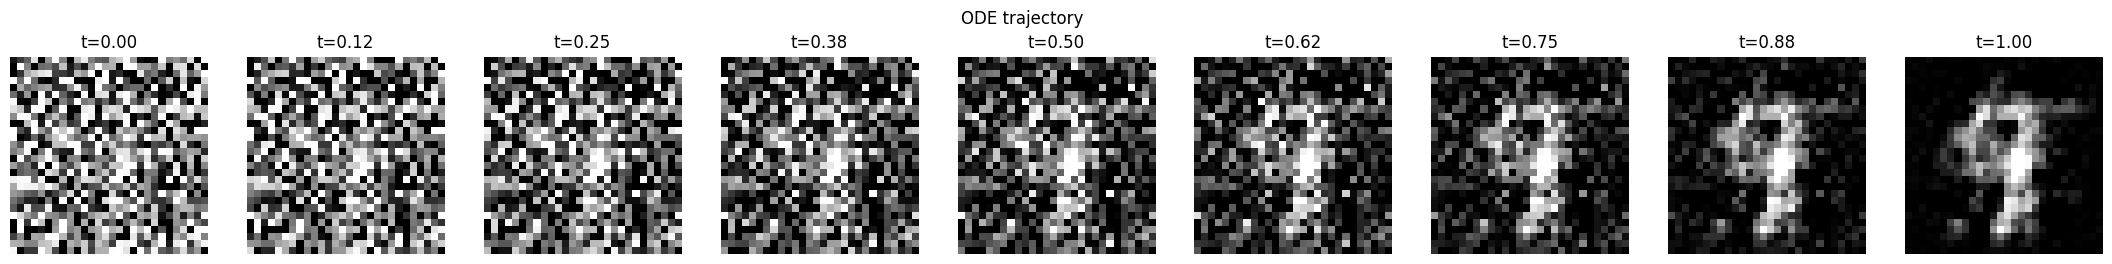

In [75]:
run_flow(dataset_base, model_new, n_steps = 2000, save_frames = 9, img_size = 28, use_random=True)